<a href="https://www.kaggle.com/code/lalit7881/anime-dataset-top-10k-normalized-eda?scriptVersionId=334700243" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_voice_actors.csv
/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_companies.csv
/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/entities.csv
/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_staff.csv
/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime.csv
/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_characters.csv
/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_genres.csv


## Loading dataset

In [2]:
import os

# Base directory
DATASET_PATH = "/kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized"

# Individual file paths
ANIME_PATH = os.path.join(DATASET_PATH, "anime.csv")
ANIME_CHARACTERS_PATH = os.path.join(DATASET_PATH, "anime_characters.csv")
ANIME_COMPANIES_PATH = os.path.join(DATASET_PATH, "anime_companies.csv")
ANIME_GENRES_PATH = os.path.join(DATASET_PATH, "anime_genres.csv")
ANIME_STAFF_PATH = os.path.join(DATASET_PATH, "anime_staff.csv")
ANIME_VOICE_ACTORS_PATH = os.path.join(DATASET_PATH, "anime_voice_actors.csv")
ENTITIES_PATH = os.path.join(DATASET_PATH, "entities.csv")

In [3]:
print("Dataset Folder :", DATASET_PATH)
print("Anime :", ANIME_PATH)
print("Characters :", ANIME_CHARACTERS_PATH)
print("Companies :", ANIME_COMPANIES_PATH)
print("Genres :", ANIME_GENRES_PATH)
print("Staff :", ANIME_STAFF_PATH)
print("Voice Actors :", ANIME_VOICE_ACTORS_PATH)
print("Entities :", ENTITIES_PATH)

Dataset Folder : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized
Anime : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime.csv
Characters : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_characters.csv
Companies : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_companies.csv
Genres : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_genres.csv
Staff : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_staff.csv
Voice Actors : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/anime_voice_actors.csv
Entities : /kaggle/input/datasets/udaykumar025/anime-dataset-top-10k-normalized/entities.csv


In [4]:
anime = pd.read_csv(ANIME_PATH)
anime_characters = pd.read_csv(ANIME_CHARACTERS_PATH)
anime_companies = pd.read_csv(ANIME_COMPANIES_PATH)
anime_genres = pd.read_csv(ANIME_GENRES_PATH)
anime_staff = pd.read_csv(ANIME_STAFF_PATH)
anime_voice_actors = pd.read_csv(ANIME_VOICE_ACTORS_PATH)
entities = pd.read_csv(ENTITIES_PATH)

In [5]:
datasets = {
    "anime": anime,
    "anime_characters": anime_characters,
    "anime_companies": anime_companies,
    "anime_genres": anime_genres,
    "anime_staff": anime_staff,
    "anime_voice_actors": anime_voice_actors,
    "entities": entities,
}

for name, df in datasets.items():
    print(f"{name:<22} Shape: {df.shape}")

anime                  Shape: (10000, 12)
anime_characters       Shape: (149536, 3)
anime_companies        Shape: (56627, 3)
anime_genres           Shape: (31164, 2)
anime_staff            Shape: (33829, 3)
anime_voice_actors     Shape: (69846, 3)
entities               Shape: (53350, 4)


In [6]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

In [7]:
datasets = {
    "anime": anime,
    "anime_characters": anime_characters,
    "anime_companies": anime_companies,
    "anime_genres": anime_genres,
    "anime_staff": anime_staff,
    "anime_voice_actors": anime_voice_actors,
    "entities": entities
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

overview = pd.DataFrame(overview)

overview

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,anime,10000,12,136,1
1,anime_characters,149536,3,0,61586
2,anime_companies,56627,3,0,5
3,anime_genres,31164,2,0,4
4,anime_staff,33829,3,0,2
5,anime_voice_actors,69846,3,0,28012
6,entities,53350,4,8864,0


In [8]:
fig = px.bar(
    overview,
    x="Dataset",
    y="Rows",
    color="Rows",
    text="Rows",
    title="Dataset Sizes"
)

fig.show()

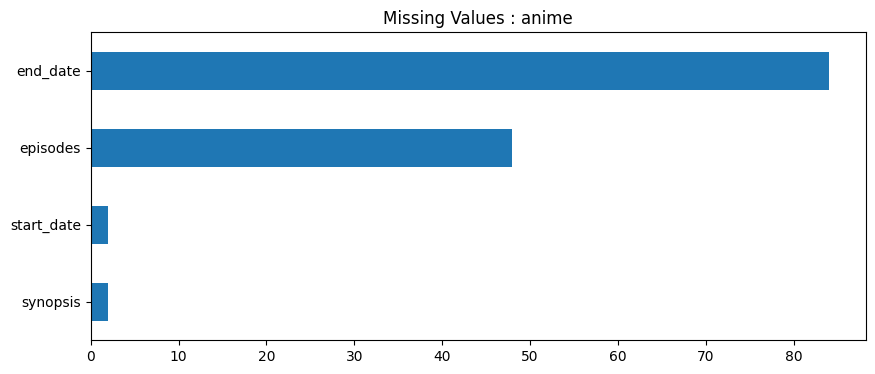

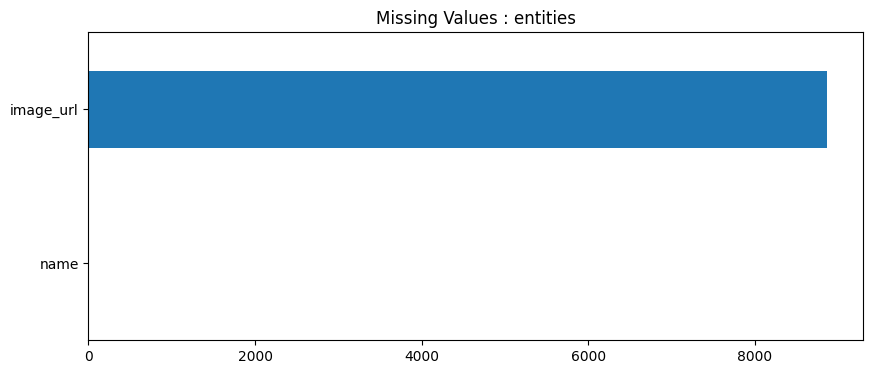

In [9]:
for name, df in datasets.items():

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing):

        plt.figure(figsize=(10,4))

        missing.sort_values().plot(kind="barh")

        plt.title(f"Missing Values : {name}")

        plt.show()

In [10]:
duplicates = []

for name, df in datasets.items():

    duplicates.append([
        name,
        df.duplicated().sum()
    ])

duplicates = pd.DataFrame(
    duplicates,
    columns=["Dataset","Duplicates"]
)

duplicates

,Dataset,Duplicates
0,anime,1
1,anime_characters,61586
2,anime_companies,5
3,anime_genres,4
4,anime_staff,2
5,anime_voice_actors,28012
6,entities,0


In [11]:
for name, df in datasets.items():

    print("="*80)

    print(name)

    print(df.dtypes)

    print()

anime
anime_id        int64
title          object
score         float64
rank            int64
popularity      int64
members         int64
synopsis       object
start_date     object
end_date       object
type           object
episodes      float64
image_url      object
dtype: object

anime_characters
anime_id         int64
character_id     int64
role            object
dtype: object

anime_companies
anime_id       int64
company_id     int64
role          object
dtype: object

anime_genres
anime_id     int64
genre       object
dtype: object

anime_staff
anime_id      int64
person_id     int64
role         object
dtype: object

anime_voice_actors
character_id     int64
person_id        int64
language        object
dtype: object

entities
entity_id       int64
entity_type    object
name           object
image_url      object
dtype: object



In [12]:
for name, df in datasets.items():

    num = df.select_dtypes(include=np.number)

    if len(num.columns):

        display(num.describe().T)

,count,mean,std,min,25%,50%,75%,max
anime_id,10000.0,24129.128000,19948.188153,1.00,4055.50,21406.0,40028.75,62863.00
score,10000.0,6.980589,0.619406,6.05,6.47,6.9,7.39,9.29
rank,10000.0,5000.494000,2886.898727,1.00,2500.75,5000.5,7500.25,10000.00
popularity,10000.0,6490.903700,4646.309341,1.00,2591.75,5564.5,9824.25,22184.00
members,10000.0,107530.875200,273351.351462,226.00,4270.25,18179.0,84692.75,4262220.00
episodes,9952.0,15.702271,41.865696,1.00,1.00,11.0,13.00,1787.00


,count,mean,std,min,25%,50%,75%,max
anime_id,149536.0,22651.793642,19735.025868,1.0,3124.0,17743.0,38550.50,62863.0
character_id,149536.0,11459.014191,15435.121159,7.0,9.0,1934.0,20595.25,53349.0


,count,mean,std,min,25%,50%,75%,max
anime_id,56627.0,26223.465043,20179.779790,1.0,5233.0,28825.0,41528.0,62863.0
company_id,56627.0,3111.014322,7421.080889,1.0,35.0,392.0,2229.0,53338.0


,count,mean,std,min,25%,50%,75%,max
anime_id,31164.0,23031.391991,20143.108408,1.0,2993.0,18053.0,39469.0,62863.0


,count,mean,std,min,25%,50%,75%,max
anime_id,33829.0,21892.956339,19574.660755,1.0,3132.0,15487.0,37984.0,62863.0
person_id,33829.0,12605.136747,13150.600011,28.0,2609.0,7532.0,18632.0,53350.0


,count,mean,std,min,25%,50%,75%,max
character_id,69846.0,20986.779171,15050.440318,7.0,7587.0,18114.0,33142.75,53345.0
person_id,69846.0,4803.963133,8177.122363,8.0,425.0,1574.0,5155.00,53281.0


,count,mean,std,min,25%,50%,75%,max
entity_id,53350.0,26675.5,15400.962768,1.0,13338.25,26675.5,40012.75,53350.0


In [13]:
for name, df in datasets.items():

    cat = df.select_dtypes(include="object")

    print("="*80)

    print(name)

    display(cat.describe().T)

anime


,count,unique,top,freq
title,10000,9999,Ling Jian Zun 4th Season,2
synopsis,9998,9762,No synopsis information has been added to this...,167
start_date,9998,68,2023-01-01,474
end_date,9916,69,2023-01-01,482
type,10000,6,TV,4330
image_url,10000,9999,https://cdn.myanimelist.net/images/anime/1972/...,2


anime_characters


,count,unique,top,freq
role,149536,149,Unknown,69846


anime_companies


...

,count,unique,top,freq
role,33829,950,Producer,13684


anime_voice_actors


,count,unique,top,freq
language,69846,1,Japanese,69846


entities


,count,unique,top,freq
entity_type,53350,6,character,39871
name,53349,51598,Gonzo,4
image_url,44487,41646,https://cdn.myanimelist.net/images/questionmar...,2823


In [14]:
for name, df in datasets.items():

    num = df.select_dtypes(include=np.number)

    for col in num.columns:

        fig = px.histogram(
            df,
            x=col,
            title=f"{name} : {col}"
        )

        fig.show()

In [15]:
for name, df in datasets.items():

    num = df.select_dtypes(include=np.number)

    for col in num.columns:

        fig = px.box(
            df,
            y=col,
            title=f"{name} : {col}"
        )

        fig.show()

In [16]:
for name, df in datasets.items():

    num = df.select_dtypes(include=np.number)

    if num.shape[1] > 1:

        corr = num.corr()

        fig = px.imshow(
            corr,
            text_auto=True,
            color_continuous_scale="RdBu_r",
            title=f"Correlation : {name}"
        )

        fig.show()

In [17]:
genre_count = (
    anime_genres["genre"]
    .value_counts()
    .head(20)
)

fig = px.bar(
    x=genre_count.index,
    y=genre_count.values,
    color=genre_count.values,
    title="Top 20 Genres"
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

In [18]:
voice = (
    anime_voice_actors["person_id"]
    .value_counts()
    .head(20)
)

fig = px.bar(
    x=voice.index.astype(str),
    y=voice.values,
    color=voice.values,
    title="Top Voice Actors"
)

fig.show()

In [19]:
characters = (
    anime_characters
    .groupby("anime_id")
    .size()
    .sort_values(ascending=False)
)

fig = px.histogram(
    x=characters.values,
    nbins=40,
    title="Characters per Anime"
)

fig.show()

In [20]:
genres = (
    anime_genres
    .groupby("anime_id")
    .size()
)

fig = px.histogram(
    x=genres.values,
    nbins=25,
    title="Genres per Anime"
)

fig.show()

In [21]:
companies = (
    anime_companies
    .groupby("anime_id")
    .size()
)

fig = px.histogram(
    x=companies.values,
    nbins=20,
    title="Companies per Anime"
)

fig.show()

In [22]:
staff = (
    anime_staff
    .groupby("anime_id")
    .size()
)

fig = px.histogram(
    x=staff.values,
    nbins=20,
    title="Staff Members per Anime"
)

fig.show()

In [23]:
relation = pd.DataFrame({
    "Table":[
        "anime",
        "anime_characters",
        "anime_companies",
        "anime_genres",
        "anime_staff",
        "anime_voice_actors",
        "entities"
    ],
    "Linked By":[
        "anime_id",
        "anime_id",
        "anime_id",
        "anime_id",
        "anime_id",
        "anime_id",
        "entity_id"
    ]
})

relation

,Table,Linked By
0,anime,anime_id
1,anime_characters,anime_id
2,anime_companies,anime_id
3,anime_genres,anime_id
4,anime_staff,anime_id
5,anime_voice_actors,anime_id
6,entities,entity_id


In [24]:
print(anime.columns.tolist())

['anime_id', 'title', 'score', 'rank', 'popularity', 'members', 'synopsis', 'start_date', 'end_date', 'type', 'episodes', 'image_url']


## Feature engineering

In [25]:
df = anime.copy()

print("="*70)
print("Original Dataset Shape :", df.shape)

# ============================================================
# Dataset Info
# ============================================================

print("\nDataset Info")
print("="*70)

display(df.head())

df.info()

# ============================================================
# Remove Duplicates
# ============================================================

print("\nDuplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates :", df.shape)

# ============================================================
# Missing Values
# ============================================================

print("\nMissing Values")
print("="*70)

missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": round(df.isnull().mean()*100,2)
})

display(missing.sort_values("Percent", ascending=False))

# ============================================================
# Convert Date Columns
# ============================================================

date_columns = ["start_date", "end_date"]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# ============================================================
# Date Features
# ============================================================

if "start_date" in df.columns:
    df["start_year"] = df["start_date"].dt.year
    df["start_month"] = df["start_date"].dt.month

if "end_date" in df.columns:
    df["end_year"] = df["end_date"].dt.year
    df["end_month"] = df["end_date"].dt.month

# ============================================================
# Numeric Columns
# ============================================================

numeric_cols = ["episodes", "members", "popularity"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# Fill Missing Values
# ============================================================

if "type" in df.columns:
    df["type"] = df["type"].fillna("Unknown")

if "synopsis" in df.columns:
    df["synopsis"] = df["synopsis"].fillna("No Synopsis")

if "title" in df.columns:
    df["title"] = df["title"].fillna("Unknown")

# ============================================================
# Remove Image URL
# ============================================================

if "image_url" in df.columns:
    df.drop(columns=["image_url"], inplace=True)

# ============================================================
# Create Target
# ============================================================

if "target" not in df.columns:

    if "score" in df.columns:

        df["target"] = (df["score"] >= 8.0).astype(int)

print("\nTarget Distribution")

print(df["target"].value_counts())

# ============================================================
# Remove Leakage Columns
# ============================================================

drop_cols = []

for col in ["score", "rank"]:
    if col in df.columns:
        drop_cols.append(col)

if len(drop_cols) > 0:
    df.drop(columns=drop_cols, inplace=True)

# ============================================================
# Remove Original Date Columns
# ============================================================

drop_dates = []

for col in ["start_date", "end_date"]:
    if col in df.columns:
        drop_dates.append(col)

if len(drop_dates) > 0:
    df.drop(columns=drop_dates, inplace=True)

# ============================================================
# Final Missing Values
# ============================================================

print("\nMissing Values After Cleaning")

display(df.isnull().sum())

# ============================================================
# Data Types
# ============================================================

print("\nData Types")

display(df.dtypes)

# ============================================================
# Numerical Features
# ============================================================

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

if "target" in numerical_features:
    numerical_features.remove("target")

print("\nNumerical Features")

print(numerical_features)

# ============================================================
# Categorical Features
# ============================================================

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nCategorical Features")

print(categorical_features)

# ============================================================
# Feature Matrix
# ============================================================

X = df.drop(columns=["target"])

y = df["target"]

print("\nFeature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

# ============================================================
# Dataset Summary
# ============================================================

summary = pd.DataFrame({
    "Feature": X.columns,
    "Datatype": X.dtypes.astype(str)
})

display(summary)

print("="*70)
print("Data Preprocessing Completed Successfully")
print("="*70)

Original Dataset Shape : (10000, 12)

Dataset Info


,anime_id,title,score,rank,popularity,members,synopsis,start_date,end_date,type,episodes,image_url
0,28977,Gintama°,9.05,8,347,680037,"Gintoki, Shinpachi, and Kagura return as the f...",2015-01-01,2016-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/3/720...
1,57555,Chainsaw Man Movie: Reze-hen,9.18,2,962,282129,Sequel to Chainsaw Man .,2025-01-01,2025-01-01,Movie,1.0,https://cdn.myanimelist.net/images/anime/1763/...
2,11061,Hunter x Hunter (2011),9.03,9,8,3107455,Hunters devote themselves to accomplishing haz...,2011-01-01,2014-01-01,TV,148.0,https://cdn.myanimelist.net/images/anime/1337/...
3,52991,Sousou no Frieren,9.29,1,121,1269074,During their decade-long quest to defeat the D...,2023-01-01,2024-01-01,TV,28.0,https://cdn.myanimelist.net/images/anime/1015/...
4,9969,Gintama',9.02,11,406,601940,"After a one-year hiatus, Shinpachi Shimura ret...",2011-01-01,2012-01-01,TV,51.0,https://cdn.myanimelist.net/images/anime/4/503...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    10000 non-null  int64  
 1   title       10000 non-null  object 
 2   score       10000 non-null  float64
 3   rank        10000 non-null  int64  
 4   popularity  10000 non-null  int64  
 5   members     10000 non-null  int64  
 6   synopsis    9998 non-null   object 
 7   start_date  9998 non-null   object 
 8   end_date    9916 non-null   object 
 9   type        10000 non-null  object 
 10  episodes    9952 non-null   float64
 11  image_url   10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB

Duplicate Rows : 1
Shape After Removing Duplicates : (9999, 12)

Missing Values


,Missing,Percent
end_date,84,0.84
episodes,48,0.48
synopsis,2,0.02
start_date,2,0.02
rank,0,0.00
score,0,0.00
title,0,0.00
anime_id,0,0.00
popularity,0,0.00
members,0,0.00



Target Distribution
target
0    9290
1     709
Name: count, dtype: int64

Missing Values After Cleaning


...


Data Types


anime_id         int64
title           object
popularity       int64
members          int64
synopsis        object
type            object
episodes       float64
start_year     float64
start_month    float64
end_year       float64
end_month      float64
target           int64
dtype: object


Numerical Features
['anime_id', 'popularity', 'members', 'episodes', 'start_year', 'start_month', 'end_year', 'end_month']

Categorical Features
['title', 'synopsis', 'type']

Feature Matrix Shape : (9999, 11)
Target Shape : (9999,)


,Feature,Datatype
anime_id,anime_id,int64
title,title,object
popularity,popularity,int64
members,members,int64
synopsis,synopsis,object
type,type,object
episodes,episodes,float64
start_year,start_year,float64
start_month,start_month,float64
end_year,end_year,float64


Data Preprocessing Completed Successfully


In [26]:
X = X.copy()

# ============================================================
# Title Features
# ============================================================

print("Creating title features...")

X["title_length"] = X["title"].astype(str).apply(len)

X["title_word_count"] = (
    X["title"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# ============================================================
# Synopsis Features
# ============================================================

print("Creating synopsis features...")

X["synopsis_length"] = (
    X["synopsis"]
    .astype(str)
    .apply(len)
)

X["synopsis_word_count"] = (
    X["synopsis"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# ============================================================
# Date Features
# ============================================================

CURRENT_YEAR = 2026

X["anime_age"] = CURRENT_YEAR - X["start_year"]

X["anime_age"] = X["anime_age"].clip(lower=0)

# ============================================================
# Duration
# ============================================================

X["airing_duration"] = (
    X["end_year"] - X["start_year"]
)

X["airing_duration"] = (
    X["airing_duration"]
    .fillna(0)
)

X["airing_duration"] = (
    X["airing_duration"]
    .clip(lower=0)
)

# ============================================================
# Episode Groups
# ============================================================

print("Creating episode groups...")

X["episode_group"] = pd.cut(

    X["episodes"],

    bins=[
        -1,
        1,
        12,
        24,
        50,
        100,
        np.inf
    ],

    labels=[
        "Movie",
        "Short",
        "One_Cour",
        "Two_Cour",
        "Long",
        "Very_Long"
    ]

)

# ============================================================
# Member Groups
# ============================================================

print("Creating member groups...")

X["member_group"] = pd.qcut(

    X["members"],

    q=4,

    labels=[
        "Low",
        "Medium",
        "High",
        "Very_High"
    ],

    duplicates="drop"

)

# ============================================================
# Popularity Groups
# ============================================================

print("Creating popularity groups...")

X["popularity_group"] = pd.qcut(

    X["popularity"],

    q=4,

    labels=[
        "Popular",
        "Moderate",
        "Less_Popular",
        "Rare"
    ],

    duplicates="drop"

)

# ============================================================
# Interaction Features
# ============================================================

print("Creating interaction features...")

X["members_per_episode"] = (
    X["members"] /
    (X["episodes"] + 1)
)

X["members_popularity_ratio"] = (
    X["members"] /
    (X["popularity"] + 1)
)

X["episodes_popularity_ratio"] = (
    X["episodes"] /
    (X["popularity"] + 1)
)

# ============================================================
# Log Features
# ============================================================

print("Creating log features...")

X["log_members"] = np.log1p(X["members"])

X["log_popularity"] = np.log1p(X["popularity"])

X["log_episodes"] = np.log1p(X["episodes"])

# ============================================================
# Rare Category Handling
# ============================================================

print("Grouping rare anime types...")

type_frequency = X["type"].value_counts()

rare_types = type_frequency[type_frequency < 20].index

X["type"] = X["type"].replace(
    rare_types,
    "Other"
)

# ============================================================
# Missing Indicators
# ============================================================

print("Creating missing indicators...")

X["episodes_missing"] = (
    X["episodes"]
    .isnull()
    .astype(int)
)

X["members_missing"] = (
    X["members"]
    .isnull()
    .astype(int)
)

X["popularity_missing"] = (
    X["popularity"]
    .isnull()
    .astype(int)
)

# ============================================================
# Remove High Cardinality Text
# ============================================================

print("Dropping raw text columns...")

X.drop(

    columns=[
        "title",
        "synopsis"
    ],

    inplace=True

)

# ============================================================
# Update Feature Lists
# ============================================================

numerical_features = X.select_dtypes(

    include=[
        "int64",
        "float64"
    ]

).columns.tolist()

categorical_features = X.select_dtypes(

    include=[
        "object",
        "category"
    ]

).columns.tolist()

# ============================================================
# Display Results
# ============================================================

print()

print("="*70)

print("Total Features :", X.shape[1])

print()

print("Numerical Features :", len(numerical_features))

print(numerical_features)

print()

print("Categorical Features :", len(categorical_features))

print(categorical_features)

print()

display(X.head())

print("="*70)

print("Feature Engineering Completed Successfully")

print("="*70)

Creating title features...
Creating synopsis features...
Creating episode groups...
Creating member groups...
Creating popularity groups...
Creating interaction features...
Creating log features...
Grouping rare anime types...
Creating missing indicators...
Dropping raw text columns...

Total Features : 27

Numerical Features : 23
['anime_id', 'popularity', 'members', 'episodes', 'start_year', 'start_month', 'end_year', 'end_month', 'title_length', 'title_word_count', 'synopsis_length', 'synopsis_word_count', 'anime_age', 'airing_duration', 'members_per_episode', 'members_popularity_ratio', 'episodes_popularity_ratio', 'log_members', 'log_popularity', 'log_episodes', 'episodes_missing', 'members_missing', 'popularity_missing']

Categorical Features : 4
['type', 'episode_group', 'member_group', 'popularity_group']



,anime_id,popularity,members,type,episodes,start_year,start_month,end_year,end_month,title_length,...,popularity_group,members_per_episode,members_popularity_ratio,episodes_popularity_ratio,log_members,log_popularity,log_episodes,episodes_missing,members_missing,popularity_missing
0,28977,347,680037,TV,51.0,2015.0,1.0,2016.0,1.0,8,...,Popular,13077.634615,1954.129310,0.146552,13.429904,5.852202,3.951244,0,0,0
1,57555,962,282129,Movie,1.0,2025.0,1.0,2025.0,1.0,28,...,Popular,141064.500000,292.968847,0.001038,12.550123,6.870053,0.693147,0,0,0
2,11061,8,3107455,TV,148.0,2011.0,1.0,2014.0,1.0,22,...,Popular,20855.402685,345272.777778,16.444444,14.949315,2.197225,5.003946,0,0,0
3,52991,121,1269074,TV,28.0,2023.0,1.0,2024.0,1.0,17,...,Popular,43761.172414,10402.245902,0.229508,14.053799,4.804021,3.367296,0,0,0
4,9969,406,601940,TV,51.0,2011.0,1.0,2012.0,1.0,8,...,Popular,11575.769231,1478.968059,0.125307,13.307915,6.008813,3.951244,0,0,0


Feature Engineering Completed Successfully


In [27]:
from sklearn.model_selection import train_test_split

print("="*70)
print("Train-Test Split")
print("="*70)

# ------------------------------------------------------------
# Feature Matrix and Target
# ------------------------------------------------------------

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

# ------------------------------------------------------------
# Target Distribution
# ------------------------------------------------------------

print("\nTarget Distribution")

print(y.value_counts())

print("\nTarget Percentage")

print(round(y.value_counts(normalize=True)*100,2))

# ------------------------------------------------------------
# Save Feature Names
# ------------------------------------------------------------

feature_names = X.columns.tolist()

# ------------------------------------------------------------
# Stratified Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y,

    shuffle=True

)

# ------------------------------------------------------------
# Shapes
# ------------------------------------------------------------

print("\nTraining Features :", X_train.shape)

print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)

print("Testing Labels    :", y_test.shape)

# ------------------------------------------------------------
# Training Distribution
# ------------------------------------------------------------

print("\nTraining Target Distribution")

train_distribution = pd.DataFrame({

    "Count": y_train.value_counts(),

    "Percentage": round(
        y_train.value_counts(normalize=True)*100,
        2
    )

})

display(train_distribution)

# ------------------------------------------------------------
# Testing Distribution
# ------------------------------------------------------------

print("\nTesting Target Distribution")

test_distribution = pd.DataFrame({

    "Count": y_test.value_counts(),

    "Percentage": round(
        y_test.value_counts(normalize=True)*100,
        2
    )

})

display(test_distribution)

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------

print("\nMissing Values (Training Set)")

display(

    X_train.isnull().sum().sort_values(
        ascending=False
    ).head(20)

)

print("\nMissing Values (Testing Set)")

display(

    X_test.isnull().sum().sort_values(
        ascending=False
    ).head(20)

)

# ------------------------------------------------------------
# Numerical Features
# ------------------------------------------------------------

print("\nNumerical Features")

print(numerical_features)

# ------------------------------------------------------------
# Categorical Features
# ------------------------------------------------------------

print("\nCategorical Features")

print(categorical_features)

# ------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------

print("\n" + "="*70)

print("Training Samples :", len(X_train))

print("Testing Samples  :", len(X_test))

print("Number of Features :", X_train.shape[1])

print("Number of Numerical Features :", len(numerical_features))

print("Number of Categorical Features :", len(categorical_features))

print("="*70)

print("Train-Test Split Completed Successfully")

print("="*70)

Train-Test Split
Feature Matrix Shape : (9999, 27)
Target Shape : (9999,)

Target Distribution
target
0    9290
1     709
Name: count, dtype: int64

Target Percentage
target
0    92.91
1     7.09
Name: proportion, dtype: float64

Training Features : (7999, 27)
Testing Features  : (2000, 27)
Training Labels   : (7999,)
Testing Labels    : (2000,)

Training Target Distribution


,Count,Percentage
target,,
0,7432,92.91
1,567,7.09



Testing Target Distribution


,Count,Percentage
target,,
0,1858,92.9
1,142,7.1



Missing Values (Training Set)


end_month                    68
end_year                     68
episodes                     37
episodes_popularity_ratio    37
log_episodes                 37
episode_group                37
members_per_episode          37
start_month                   2
start_year                    2
anime_age                     2
anime_id                      0
title_word_count              0
title_length                  0
type                          0
members                       0
popularity                    0
synopsis_word_count           0
airing_duration               0
synopsis_length               0
popularity_group              0
dtype: int64


Missing Values (Testing Set)


end_month                    16
end_year                     16
episodes                     11
episodes_popularity_ratio    11
log_episodes                 11
episode_group                11
members_per_episode          11
members                       0
popularity                    0
anime_id                      0
type                          0
title_word_count              0
title_length                  0
start_year                    0
start_month                   0
airing_duration               0
anime_age                     0
synopsis_length               0
synopsis_word_count           0
popularity_group              0
dtype: int64


Numerical Features
['anime_id', 'popularity', 'members', 'episodes', 'start_year', 'start_month', 'end_year', 'end_month', 'title_length', 'title_word_count', 'synopsis_length', 'synopsis_word_count', 'anime_age', 'airing_duration', 'members_per_episode', 'members_popularity_ratio', 'episodes_popularity_ratio', 'log_members', 'log_popularity', 'log_episodes', 'episodes_missing', 'members_missing', 'popularity_missing']

Categorical Features
['type', 'episode_group', 'member_group', 'popularity_group']

Training Samples : 7999
Testing Samples  : 2000
Number of Features : 27
Number of Numerical Features : 23
Number of Categorical Features : 4
Train-Test Split Completed Successfully


In [28]:
# ============================================================
# Part 4 : Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

print("="*70)
print("Creating Preprocessing Pipeline")
print("="*70)

# ============================================================
# Numerical Pipeline
# ============================================================

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "scaler",

            StandardScaler()

        )

    ]

)

# ============================================================
# Categorical Pipeline
# ============================================================

categorical_transformer = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )

        ),

        (

            "encoder",

            OneHotEncoder(

                handle_unknown="ignore",

                sparse_output=False

            )

        )

    ]

)

# ============================================================
# Column Transformer
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numerical_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ],

    remainder="drop"

)

# ============================================================
# Fit ONLY on Training Data
# ============================================================

print("Fitting preprocessing pipeline on training data...")

X_train_processed = preprocessor.fit_transform(X_train)

print("Transforming testing data...")

X_test_processed = preprocessor.transform(X_test)

# ============================================================
# Feature Names
# ============================================================

encoded_features = preprocessor.named_transformers_[

    "cat"

].named_steps[

    "encoder"

].get_feature_names_out(

    categorical_features

)

processed_feature_names = (

    numerical_features +

    list(encoded_features)

)

# ============================================================
# Convert to DataFrame
# ============================================================

X_train_processed = pd.DataFrame(

    X_train_processed,

    columns=processed_feature_names,

    index=X_train.index

)

X_test_processed = pd.DataFrame(

    X_test_processed,

    columns=processed_feature_names,

    index=X_test.index

)

# ============================================================
# Check Shapes
# ============================================================

print()

print("Training Shape")

print(X_train_processed.shape)

print()

print("Testing Shape")

print(X_test_processed.shape)

# ============================================================
# Missing Values
# ============================================================

print()

print("Missing Values in Training")

print(

    X_train_processed.isnull().sum().sum()

)

print()

print("Missing Values in Testing")

print(

    X_test_processed.isnull().sum().sum()

)

# ============================================================
# Display Sample
# ============================================================

print()

display(

    X_train_processed.head()

)

# ============================================================
# Verify Feature Names
# ============================================================

print()

print("Total Features After Encoding")

print(len(processed_feature_names))

print()

print(processed_feature_names[:30])

# ============================================================
# Summary
# ============================================================

print()

print("="*70)

print("Preprocessing Completed Successfully")

print("="*70)

Creating Preprocessing Pipeline
Fitting preprocessing pipeline on training data...
Transforming testing data...

Training Shape
(7999, 43)

Testing Shape
(2000, 43)

Missing Values in Training
0

Missing Values in Testing
0



,anime_id,popularity,members,episodes,start_year,start_month,end_year,end_month,title_length,title_word_count,...,episode_group_Two_Cour,episode_group_Very_Long,member_group_High,member_group_Low,member_group_Medium,member_group_Very_High,popularity_group_Less_Popular,popularity_group_Moderate,popularity_group_Popular,popularity_group_Rare
599,0.499817,-0.770203,-0.140739,-0.087872,0.572836,0.0,0.562528,0.0,-0.682117,-0.567314,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9747,-0.959620,1.291616,-0.380398,-0.339770,-1.981848,0.0,-2.042414,0.0,0.384738,0.138981,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9414,0.448765,0.365235,-0.362699,-0.293970,0.490427,0.0,0.478497,0.0,-1.156275,-0.920462,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
8370,-1.012073,1.785285,-0.383649,1.927312,-1.075347,0.0,-0.950019,0.0,0.206929,-0.214167,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6548,1.721912,2.038129,-0.384640,0.828121,1.149700,0.0,1.234771,0.0,-0.800656,-0.567314,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0



Total Features After Encoding
43

['anime_id', 'popularity', 'members', 'episodes', 'start_year', 'start_month', 'end_year', 'end_month', 'title_length', 'title_word_count', 'synopsis_length', 'synopsis_word_count', 'anime_age', 'airing_duration', 'members_per_episode', 'members_popularity_ratio', 'episodes_popularity_ratio', 'log_members', 'log_popularity', 'log_episodes', 'episodes_missing', 'members_missing', 'popularity_missing', 'type_Movie', 'type_ONA', 'type_OVA', 'type_Special', 'type_TV', 'type_TV Special', 'episode_group_Long']

Preprocessing Completed Successfully


Logistic Regression
Training Logistic Regression...

Training Accuracy : 0.9394
Testing Accuracy  : 0.9385

Precision : 0.6557
Recall    : 0.2817
F1 Score  : 0.3941
ROC AUC   : 0.8934


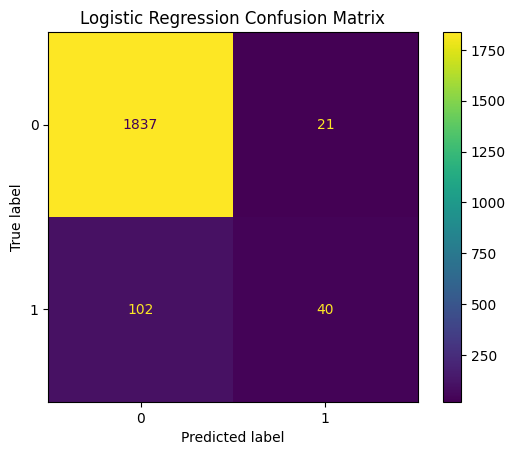


Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1858
           1       0.66      0.28      0.39       142

    accuracy                           0.94      2000
   macro avg       0.80      0.64      0.68      2000
weighted avg       0.93      0.94      0.93      2000

Cross Validation
Fold Scores
[0.944375 0.94125  0.935625 0.94     0.931207]

Mean CV Accuracy : 0.9385
Std CV Accuracy : 0.0046

Top 20 Important Features


,Feature,Coefficient,AbsCoefficient
27,type_TV,-1.762478,1.762478
10,synopsis_length,1.335173,1.335173
17,log_members,1.274944,1.274944
11,synopsis_word_count,-1.171367,1.171367
30,episode_group_Movie,-1.087818,1.087818
32,episode_group_Short,-1.082096,1.082096
23,type_Movie,0.936687,0.936687
18,log_popularity,-0.935006,0.935006
1,popularity,-0.894132,0.894132
0,anime_id,0.765088,0.765088



Logistic Regression Training Completed Successfully


In [29]:
# ============================================================
# Part 5A-1 : Logistic Regression
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.model_selection import cross_val_score

print("="*70)
print("Logistic Regression")
print("="*70)

# ============================================================
# Model
# ============================================================

lr_model = LogisticRegression(

    random_state=42,

    max_iter=1000,

    solver="lbfgs"

)

# ============================================================
# Train Model
# ============================================================

print("Training Logistic Regression...\n")

lr_model.fit(

    X_train_processed,

    y_train

)

# ============================================================
# Prediction
# ============================================================

lr_train_pred = lr_model.predict(

    X_train_processed

)

lr_test_pred = lr_model.predict(

    X_test_processed

)

# ============================================================
# Prediction Probability
# ============================================================

lr_train_prob = lr_model.predict_proba(

    X_train_processed

)[:,1]

lr_test_prob = lr_model.predict_proba(

    X_test_processed

)[:,1]

# ============================================================
# Metrics
# ============================================================

lr_train_accuracy = accuracy_score(

    y_train,

    lr_train_pred

)

lr_test_accuracy = accuracy_score(

    y_test,

    lr_test_pred

)

lr_precision = precision_score(

    y_test,

    lr_test_pred

)

lr_recall = recall_score(

    y_test,

    lr_test_pred

)

lr_f1 = f1_score(

    y_test,

    lr_test_pred

)

lr_auc = roc_auc_score(

    y_test,

    lr_test_prob

)

# ============================================================
# Print Metrics
# ============================================================

print("="*70)

print("Training Accuracy :", round(

    lr_train_accuracy,

    4

))

print("Testing Accuracy  :", round(

    lr_test_accuracy,

    4

))

print()

print("Precision :", round(

    lr_precision,

    4

))

print("Recall    :", round(

    lr_recall,

    4

))

print("F1 Score  :", round(

    lr_f1,

    4

))

print("ROC AUC   :", round(

    lr_auc,

    4

))

print("="*70)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    lr_test_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title(

    "Logistic Regression Confusion Matrix"

)

plt.show()

# ============================================================
# Classification Report
# ============================================================

print()

print("="*70)

print("Classification Report")

print("="*70)

print(

    classification_report(

        y_test,

        lr_test_pred

    )

)

# ============================================================
# Cross Validation
# ============================================================

print("="*70)

print("Cross Validation")

print("="*70)

cv_scores = cross_val_score(

    lr_model,

    X_train_processed,

    y_train,

    cv=5,

    scoring="accuracy"

)

print("Fold Scores")

print(cv_scores)

print()

print("Mean CV Accuracy :", round(

    cv_scores.mean(),

    4

))

print("Std CV Accuracy :", round(

    cv_scores.std(),

    4

))

# ============================================================
# Save Model
# ============================================================

trained_models = {}

trained_models["Logistic Regression"] = lr_model

# ============================================================
# Save Results
# ============================================================

model_results = []

model_results.append({

    "Model":"Logistic Regression",

    "Train Accuracy":lr_train_accuracy,

    "Test Accuracy":lr_test_accuracy,

    "Precision":lr_precision,

    "Recall":lr_recall,

    "F1 Score":lr_f1,

    "ROC AUC":lr_auc,

    "CV Accuracy":cv_scores.mean()

})

# ============================================================
# Store Predictions
# ============================================================

predictions = {}

predictions["Logistic Regression"] = {

    "y_pred":lr_test_pred,

    "y_prob":lr_test_prob

}

# ============================================================
# Feature Coefficients
# ============================================================

coef_df = pd.DataFrame({

    "Feature":processed_feature_names,

    "Coefficient":lr_model.coef_[0]

})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(

    by="AbsCoefficient",

    ascending=False

)

print()

print("="*70)

print("Top 20 Important Features")

print("="*70)

display(

    coef_df.head(20)

)

# ============================================================
# Completed
# ============================================================

print()

print("="*70)

print("Logistic Regression Training Completed Successfully")

print("="*70)

K-Nearest Neighbors (KNN)
Training KNN...

Training Accuracy : 1.0
Testing Accuracy  : 0.9345

Precision : 0.5932
Recall    : 0.2465
F1 Score  : 0.3483
ROC AUC   : 0.8251


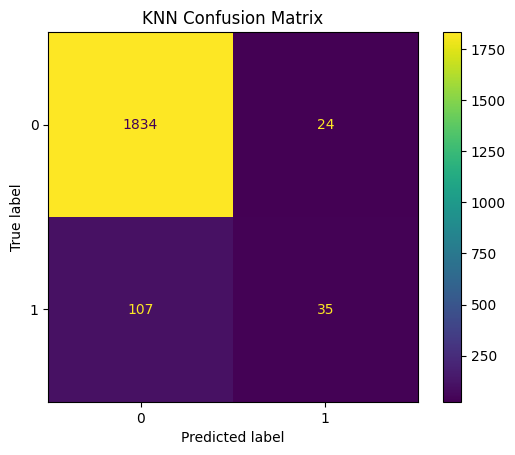


Classification Report
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      1858
           1       0.59      0.25      0.35       142

    accuracy                           0.93      2000
   macro avg       0.77      0.62      0.66      2000
weighted avg       0.92      0.93      0.92      2000

Cross Validation
Fold Accuracy
[0.93375    0.93125    0.934375   0.935625   0.92995622]

Mean Accuracy : 0.933
Std Accuracy : 0.0021

KNN Parameters
Number of Neighbors : 7
Weights : distance
Distance Metric : minkowski

KNN Training Completed Successfully


In [30]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.model_selection import cross_val_score

print("="*70)
print("K-Nearest Neighbors (KNN)")
print("="*70)

# ============================================================
# Model
# ============================================================

knn_model = KNeighborsClassifier(

    n_neighbors=7,

    weights="distance",

    metric="minkowski",

    p=2

)

# ============================================================
# Train
# ============================================================

print("Training KNN...\n")

knn_model.fit(

    X_train_processed,

    y_train

)

# ============================================================
# Prediction
# ============================================================

knn_train_pred = knn_model.predict(

    X_train_processed

)

knn_test_pred = knn_model.predict(

    X_test_processed

)

# ============================================================
# Probability
# ============================================================

knn_train_prob = knn_model.predict_proba(

    X_train_processed

)[:,1]

knn_test_prob = knn_model.predict_proba(

    X_test_processed

)[:,1]

# ============================================================
# Metrics
# ============================================================

knn_train_accuracy = accuracy_score(

    y_train,

    knn_train_pred

)

knn_test_accuracy = accuracy_score(

    y_test,

    knn_test_pred

)

knn_precision = precision_score(

    y_test,

    knn_test_pred

)

knn_recall = recall_score(

    y_test,

    knn_test_pred

)

knn_f1 = f1_score(

    y_test,

    knn_test_pred

)

knn_auc = roc_auc_score(

    y_test,

    knn_test_prob

)

# ============================================================
# Print Metrics
# ============================================================

print("="*70)

print("Training Accuracy :", round(knn_train_accuracy,4))
print("Testing Accuracy  :", round(knn_test_accuracy,4))

print()

print("Precision :", round(knn_precision,4))
print("Recall    :", round(knn_recall,4))
print("F1 Score  :", round(knn_f1,4))
print("ROC AUC   :", round(knn_auc,4))

print("="*70)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    knn_test_pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title("KNN Confusion Matrix")

plt.show()

# ============================================================
# Classification Report
# ============================================================

print()

print("="*70)
print("Classification Report")
print("="*70)

print(

    classification_report(

        y_test,

        knn_test_pred

    )

)

# ============================================================
# Cross Validation
# ============================================================

print("="*70)
print("Cross Validation")
print("="*70)

cv_scores = cross_val_score(

    knn_model,

    X_train_processed,

    y_train,

    cv=5,

    scoring="accuracy"

)

print("Fold Accuracy")

print(cv_scores)

print()

print("Mean Accuracy :", round(

    cv_scores.mean(),

    4

))

print("Std Accuracy :", round(

    cv_scores.std(),

    4

))

# ============================================================
# Save Model
# ============================================================

trained_models["KNN"] = knn_model

# ============================================================
# Save Results
# ============================================================

model_results.append({

    "Model":"KNN",

    "Train Accuracy":knn_train_accuracy,

    "Test Accuracy":knn_test_accuracy,

    "Precision":knn_precision,

    "Recall":knn_recall,

    "F1 Score":knn_f1,

    "ROC AUC":knn_auc,

    "CV Accuracy":cv_scores.mean()

})

# ============================================================
# Save Predictions
# ============================================================

predictions["KNN"] = {

    "y_pred":knn_test_pred,

    "y_prob":knn_test_prob

}

# ============================================================
# Neighbor Information
# ============================================================

print()

print("="*70)

print("KNN Parameters")

print("="*70)

print("Number of Neighbors :", knn_model.n_neighbors)

print("Weights :", knn_model.weights)

print("Distance Metric :", knn_model.metric)

print()

# ============================================================
# Completed
# ============================================================

print("="*70)

print("KNN Training Completed Successfully")

print("="*70)

Decision Tree Classifier
Training Decision Tree...

Training Accuracy : 0.9577
Testing Accuracy  : 0.931

Precision : 0.5213
Recall    : 0.3451
F1 Score  : 0.4153
ROC AUC   : 0.8051


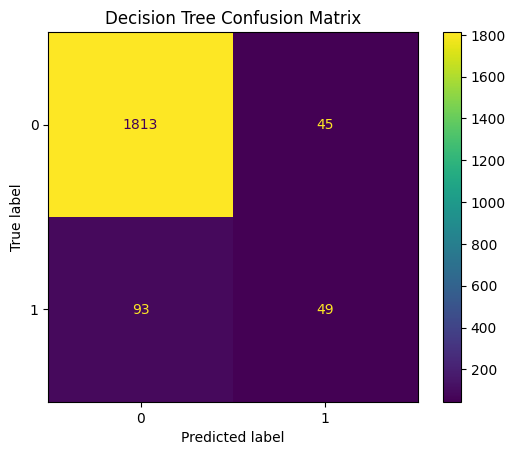


Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1858
           1       0.52      0.35      0.42       142

    accuracy                           0.93      2000
   macro avg       0.74      0.66      0.69      2000
weighted avg       0.92      0.93      0.92      2000

Cross Validation
Fold Accuracy
[0.924375   0.92625    0.921875   0.92375    0.92620388]

Mean Accuracy : 0.9245
Std Accuracy  : 0.0016

Top 20 Important Features


,Feature,Importance
17,log_members,0.306462
16,episodes_popularity_ratio,0.113957
14,members_per_episode,0.113927
0,anime_id,0.081740
8,title_length,0.067353
10,synopsis_length,0.060728
2,members,0.051267
11,synopsis_word_count,0.042087
1,popularity,0.020535
6,end_year,0.018943



Tree Depth : 10
Leaf Nodes : 183

Decision Tree Training Completed Successfully


In [31]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.model_selection import cross_val_score

print("="*70)
print("Decision Tree Classifier")
print("="*70)

# ============================================================
# Model
# ============================================================

dt_model = DecisionTreeClassifier(

    criterion="gini",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42

)

# ============================================================
# Train Model
# ============================================================

print("Training Decision Tree...\n")

dt_model.fit(
    X_train_processed,
    y_train
)

# ============================================================
# Prediction
# ============================================================

dt_train_pred = dt_model.predict(X_train_processed)

dt_test_pred = dt_model.predict(X_test_processed)

# ============================================================
# Probability Prediction
# ============================================================

dt_train_prob = dt_model.predict_proba(
    X_train_processed
)[:,1]

dt_test_prob = dt_model.predict_proba(
    X_test_processed
)[:,1]

# ============================================================
# Metrics
# ============================================================

dt_train_accuracy = accuracy_score(
    y_train,
    dt_train_pred
)

dt_test_accuracy = accuracy_score(
    y_test,
    dt_test_pred
)

dt_precision = precision_score(
    y_test,
    dt_test_pred
)

dt_recall = recall_score(
    y_test,
    dt_test_pred
)

dt_f1 = f1_score(
    y_test,
    dt_test_pred
)

dt_auc = roc_auc_score(
    y_test,
    dt_test_prob
)

# ============================================================
# Print Metrics
# ============================================================

print("="*70)

print("Training Accuracy :", round(dt_train_accuracy,4))
print("Testing Accuracy  :", round(dt_test_accuracy,4))

print()

print("Precision :", round(dt_precision,4))
print("Recall    :", round(dt_recall,4))
print("F1 Score  :", round(dt_f1,4))
print("ROC AUC   :", round(dt_auc,4))

print("="*70)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    dt_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()

# ============================================================
# Classification Report
# ============================================================

print()

print("="*70)
print("Classification Report")
print("="*70)

print(

    classification_report(

        y_test,

        dt_test_pred

    )

)

# ============================================================
# Cross Validation
# ============================================================

print("="*70)
print("Cross Validation")
print("="*70)

cv_scores = cross_val_score(

    dt_model,

    X_train_processed,

    y_train,

    cv=5,

    scoring="accuracy"

)

print("Fold Accuracy")

print(cv_scores)

print()

print("Mean Accuracy :", round(cv_scores.mean(),4))

print("Std Accuracy  :", round(cv_scores.std(),4))

# ============================================================
# Feature Importance
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": processed_feature_names,

    "Importance": dt_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

print()

print("="*70)
print("Top 20 Important Features")
print("="*70)

display(feature_importance.head(20))

# ============================================================
# Save Model
# ============================================================

trained_models["Decision Tree"] = dt_model

# ============================================================
# Save Results
# ============================================================

model_results.append({

    "Model":"Decision Tree",

    "Train Accuracy":dt_train_accuracy,

    "Test Accuracy":dt_test_accuracy,

    "Precision":dt_precision,

    "Recall":dt_recall,

    "F1 Score":dt_f1,

    "ROC AUC":dt_auc,

    "CV Accuracy":cv_scores.mean()

})

# ============================================================
# Save Predictions
# ============================================================

predictions["Decision Tree"] = {

    "y_pred":dt_test_pred,

    "y_prob":dt_test_prob

}

# ============================================================
# Tree Information
# ============================================================

print()

print("="*70)

print("Tree Depth :", dt_model.get_depth())

print("Leaf Nodes :", dt_model.get_n_leaves())

print("="*70)

# ============================================================
# Completed
# ============================================================

print()

print("="*70)

print("Decision Tree Training Completed Successfully")

print("="*70)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy
0,Logistic Regression,0.9394,0.9385,0.6557,0.2817,0.3941,0.8934,0.9385
1,KNN,1.0000,0.9345,0.5932,0.2465,0.3483,0.8251,0.9330
2,Decision Tree,0.9577,0.9310,0.5213,0.3451,0.4153,0.8051,0.9245


,Rank,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Accuracy
0,1,Logistic Regression,0.9394,0.9385,0.6557,0.2817,0.3941,0.8934,0.9385
1,2,KNN,1.0000,0.9345,0.5932,0.2465,0.3483,0.8251,0.9330
2,3,Decision Tree,0.9577,0.9310,0.5213,0.3451,0.4153,0.8051,0.9245



Best Model : Logistic Regression

LogisticRegression(max_iter=1000, random_state=42)


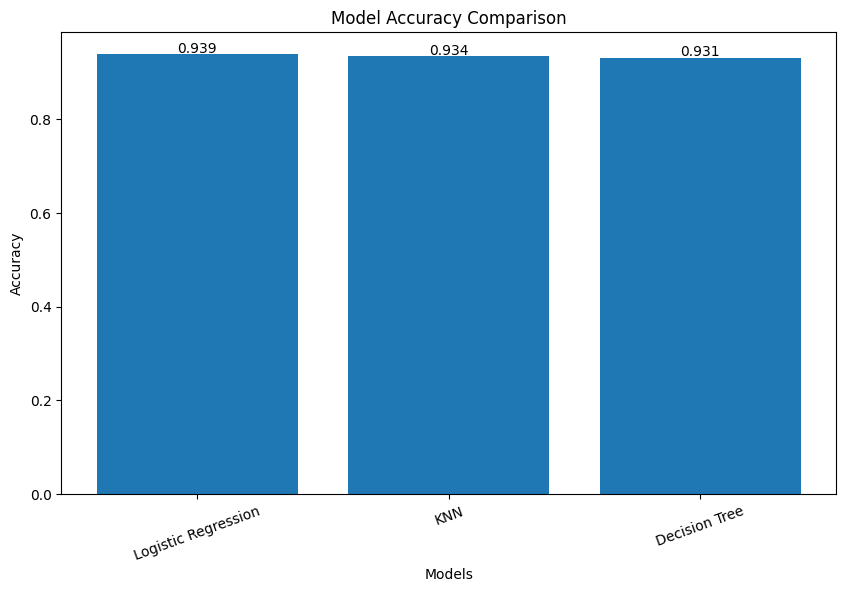

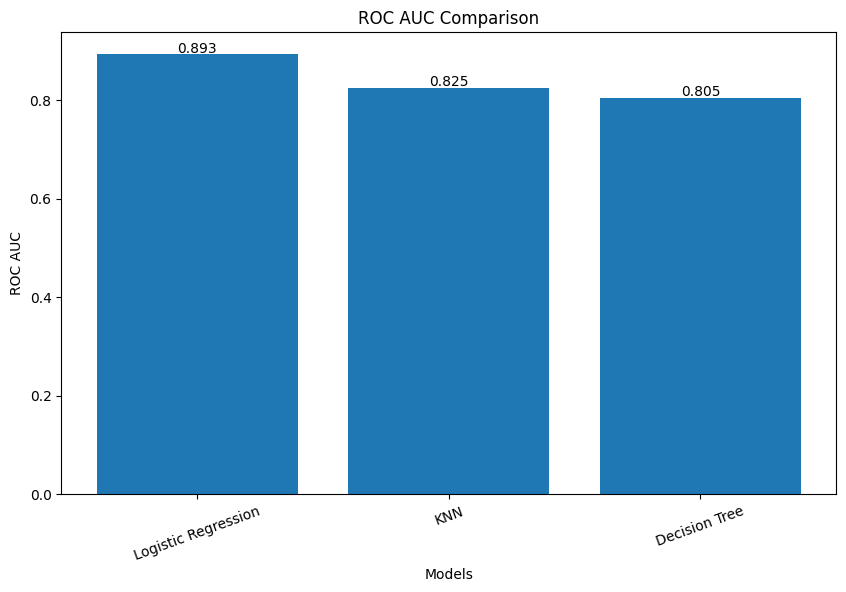

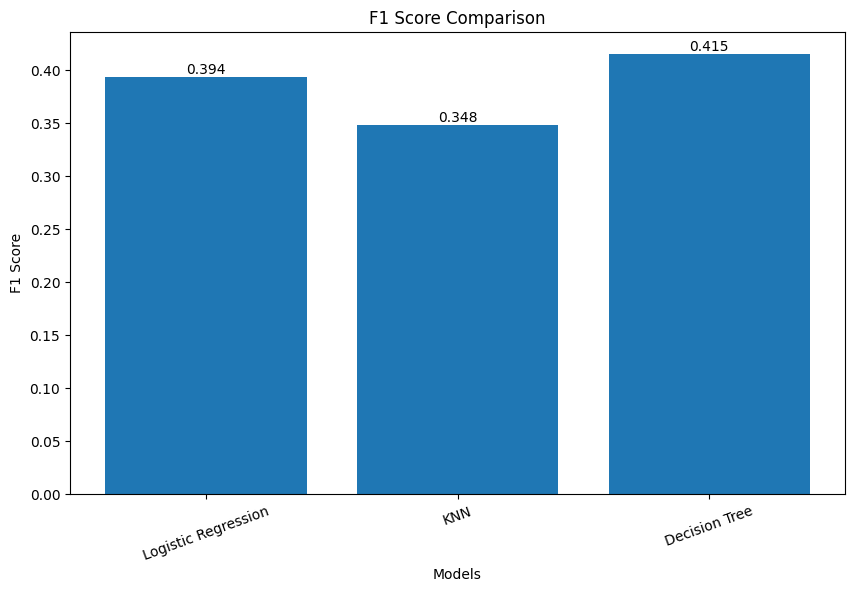


Prediction Objects Created
dict_keys(['Logistic Regression', 'KNN', 'Decision Tree'])

Saved : Part5A_Model_Comparison.csv

Prediction Files Saved

Available Objects

trained_models
predictions
prediction_summary
results_df
best_model
best_model_name

Part 5A Completed Successfully


In [32]:
results_df = pd.DataFrame(model_results)

results_df = results_df.round(4)

results_df = results_df.sort_values(

    by="Test Accuracy",

    ascending=False

).reset_index(drop=True)

display(results_df)

# ============================================================
# Ranking
# ============================================================

results_df["Rank"] = np.arange(1, len(results_df)+1)

results_df = results_df[

    [

        "Rank",

        "Model",

        "Train Accuracy",

        "Test Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC",

        "CV Accuracy"

    ]

]

display(results_df)

# ============================================================
# Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print()

print("="*80)

print("Best Model :", best_model_name)

print()

print(best_model)

print("="*80)

# ============================================================
# Accuracy Plot
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(

    results_df["Model"],

    results_df["Test Accuracy"]

)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

for i,v in enumerate(results_df["Test Accuracy"]):

    plt.text(

        i,

        v+0.003,

        f"{v:.3f}",

        ha="center",

        fontsize=10

    )

plt.show()

# ============================================================
# ROC AUC Plot
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(

    results_df["Model"],

    results_df["ROC AUC"]

)

plt.title("ROC AUC Comparison")

plt.xlabel("Models")

plt.ylabel("ROC AUC")

plt.xticks(rotation=20)

for i,v in enumerate(results_df["ROC AUC"]):

    plt.text(

        i,

        v+0.003,

        f"{v:.3f}",

        ha="center",

        fontsize=10

    )

plt.show()

# ============================================================
# F1 Score Plot
# ============================================================

plt.figure(figsize=(10,6))

plt.bar(

    results_df["Model"],

    results_df["F1 Score"]

)

plt.title("F1 Score Comparison")

plt.xlabel("Models")

plt.ylabel("F1 Score")

plt.xticks(rotation=20)

for i,v in enumerate(results_df["F1 Score"]):

    plt.text(

        i,

        v+0.003,

        f"{v:.3f}",

        ha="center",

        fontsize=10

    )

plt.show()

# ============================================================
# Store Prediction Data
# ============================================================

prediction_summary = {}

for model in predictions:

    prediction_summary[model] = pd.DataFrame({

        "Actual": y_test.values,

        "Prediction": predictions[model]["y_pred"],

        "Probability": predictions[model]["y_prob"]

    })

print()

print("Prediction Objects Created")

print(prediction_summary.keys())

# ============================================================
# Save CSV Files
# ============================================================

results_df.to_csv(

    "Part5A_Model_Comparison.csv",

    index=False

)

print()

print("Saved : Part5A_Model_Comparison.csv")

# ============================================================
# Save Individual Prediction Files
# ============================================================

for model in prediction_summary:

    filename = (

        model

        .replace(" ","_")

        + "_Predictions.csv"

    )

    prediction_summary[model].to_csv(

        filename,

        index=False

    )

print()

print("Prediction Files Saved")

# ============================================================
# Objects Available
# ============================================================

print()

print("="*80)

print("Available Objects")

print("="*80)

print()

print("trained_models")

print("predictions")

print("prediction_summary")

print("results_df")

print("best_model")

print("best_model_name")

print()

print("="*80)

print("Part 5A Completed Successfully")

print("="*80)

## Thank you..pls upvote!!!!!!!!!!!